# HW5 Basis Expansions and Piecewise Fits

**IEOR 4578 Forecasting**
Luca Barattini (UNI: LB3656)

This notebook executes every chunk of `Basis.py` and answers both questions of HW5.

**Q1 [50 pts]** Apply four basis-expansion fits to a noisy cosine signal:
1. Piecewise constant fit
2. Piecewise linear fit
3. Continuous Piecewise Linear
4. Continuous Cubic Spline

**Q2 [50 pts]** Apply the same four fits to `WholeFood.xlsx` weekly sales, and explain why the continuous cubic spline is a poor fit for that series.


In [1]:
import os
# Imports trimmed to the libraries actually used in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg

np.random.seed(42)

os.makedirs("images", exist_ok=True)


# Question 1 Noisy Cosine Signal

Generate $50$ samples from $y = \cos(x)$ on the interval $[-1, 7]$, perturbed by Gaussian noise with $\sigma = 0.5$. Two interior knots split the domain into three regions:
$$x_{\min} = -1, \qquad x_{\text{knot}_1} = 1.5, \qquad x_{\text{knot}_2} = 4.5, \qquad x_{\max} = 7.$$


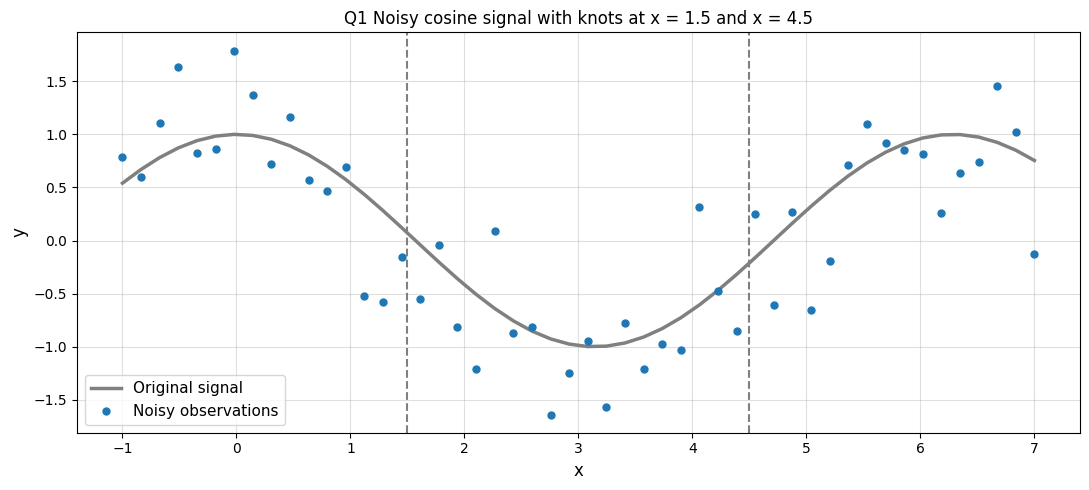

In [2]:
# Axes limits and knots (exactly as in Basis.py)
x_min, x_knot_1, x_knot_2, x_max = -1, 1.5, 4.5, 7

# Points generated from a cosine function with normal noise
x_true = np.linspace(x_min, x_max, 50)
y_true = np.cos(x_true)
y_obs  = y_true + np.random.normal(scale=0.5, size=len(x_true))

# Pre-compute per-region slices (used by the piecewise fits below)
mask_1 = x_true <= x_knot_1
mask_2 = (x_knot_1 < x_true) & (x_true < x_knot_2)
mask_3 = x_true >= x_knot_2

x_region_1, y_region_1 = x_true[mask_1], y_true[mask_1]
x_region_2, y_region_2 = x_true[mask_2], y_true[mask_2]
x_region_3, y_region_3 = x_true[mask_3], y_true[mask_3]

# Visualise the raw data and the knot positions
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, linewidth=2.5, c='gray', label='Original signal')
ax.plot(x_true, y_obs,  'o', markersize=5, label='Noisy observations')
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q1 Noisy cosine signal with knots at x = 1.5 and x = 4.5')
plt.tight_layout()
plt.savefig('images/Q1_signal.png', dpi=130)
plt.show()


## 1.1 Piecewise Constant Fit

Within each of the three regions defined by the knots, replace the data with the **regional mean**:
$$\hat{y}(x) \;=\; \bar{y}_{\text{region}(x)}.$$

This is the simplest possible local fit: the function is piecewise constant, with three jumps at the knots. It captures the *level* of the signal in each region but cannot represent any local trend.


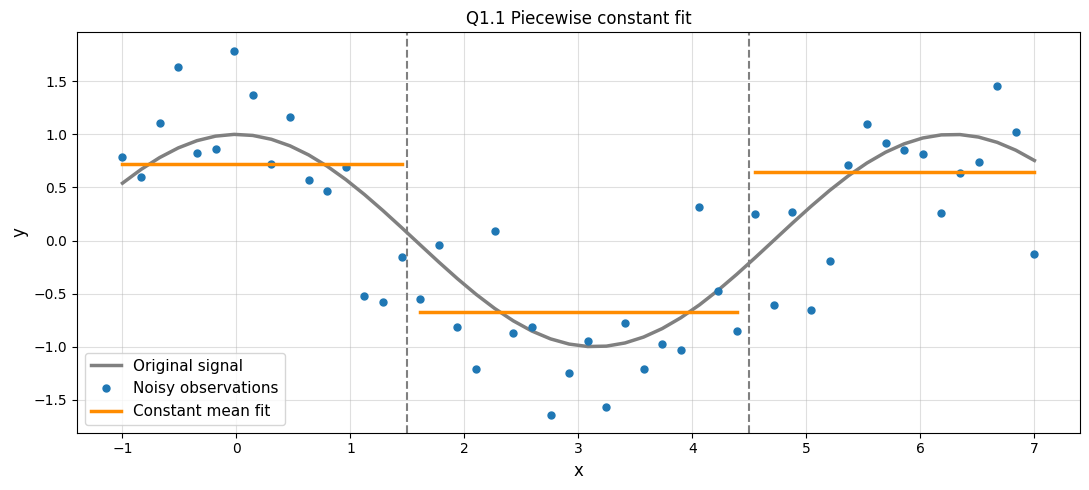

Region 1 mean: 0.7212
Region 2 mean: -0.6710
Region 3 mean: 0.6465


In [3]:
# Piecewise constant fit
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, linewidth=2.5, c='gray', label='Original signal')
ax.plot(x_true, y_obs,  'o', markersize=5, label='Noisy observations')

# Plot the three regional means (use plot, not axhline, so each line stays inside its region)
ax.plot(x_region_1, np.full_like(x_region_1, y_region_1.mean()), c='darkorange', linewidth=2.5, label='Constant mean fit')
ax.plot(x_region_2, np.full_like(x_region_2, y_region_2.mean()), c='darkorange', linewidth=2.5)
ax.plot(x_region_3, np.full_like(x_region_3, y_region_3.mean()), c='darkorange', linewidth=2.5)

ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q1.1 Piecewise constant fit')
plt.tight_layout()
plt.savefig('images/Q1_piecewise_constant.png', dpi=130)
plt.show()

print(f"Region 1 mean: {y_region_1.mean():.4f}")
print(f"Region 2 mean: {y_region_2.mean():.4f}")
print(f"Region 3 mean: {y_region_3.mean():.4f}")


## 1.2 Piecewise Linear Fit

Inside each region fit an independent simple linear regression $y = \alpha_r + \beta_r x$ via the regression-anatomy formula
$$\hat{\beta}_r \;=\; \frac{(y_r - \bar{y}_r) \cdot x_r}{\sum x_r^2}, \qquad \hat{\alpha}_r \;=\; \bar{y}_r.$$

The fit is more flexible than the piecewise constant version because it now captures the *slope* in each region, but the three lines are estimated independently and therefore **discontinuous** at the knots.


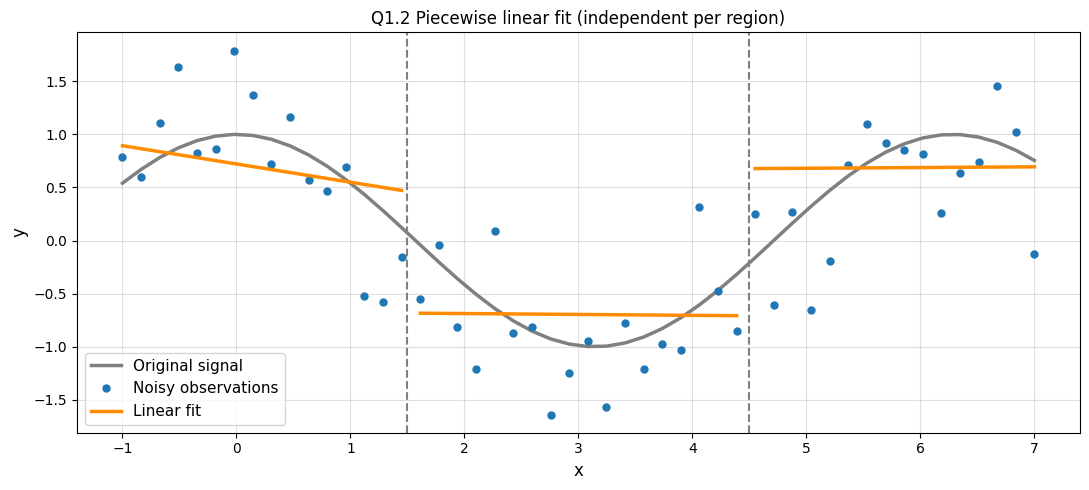

Region 1 slope: -0.1719
Region 2 slope: -0.0083
Region 3 slope: 0.0068


In [4]:
# Piecewise linear fit (independent OLS per region, regression-anatomy form)
beta_region_1 = ((y_region_1 - y_region_1.mean()).dot(x_region_1) / (x_region_1**2).sum())
beta_region_2 = ((y_region_2 - y_region_2.mean()).dot(x_region_2) / (x_region_2**2).sum())
beta_region_3 = ((y_region_3 - y_region_3.mean()).dot(x_region_3) / (x_region_3**2).sum())

y_hat_region_1 = beta_region_1 * x_region_1 + y_region_1.mean()
y_hat_region_2 = beta_region_2 * x_region_2 + y_region_2.mean()
y_hat_region_3 = beta_region_3 * x_region_3 + y_region_3.mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, linewidth=2.5, c='gray', label='Original signal')
ax.plot(x_true, y_obs,  'o', markersize=5, label='Noisy observations')
ax.plot(x_region_1, y_hat_region_1, c='darkorange', linewidth=2.5, label='Linear fit')
ax.plot(x_region_2, y_hat_region_2, c='darkorange', linewidth=2.5)
ax.plot(x_region_3, y_hat_region_3, c='darkorange', linewidth=2.5)
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q1.2 Piecewise linear fit (independent per region)')
plt.tight_layout()
plt.savefig('images/Q1_piecewise_linear.png', dpi=130)
plt.show()

print(f"Region 1 slope: {beta_region_1:.4f}")
print(f"Region 2 slope: {beta_region_2:.4f}")
print(f"Region 3 slope: {beta_region_3:.4f}")


## 1.3 Continuous Piecewise Linear

Use a **basis expansion** so that the regression is fitted *jointly* across all regions and the fit is forced to be continuous at the knots:
$$\hat{y}(x) \;=\; \beta_0 \, h_1(x) + \beta_1 \, h_2(x) + \beta_2 \, h_3(x) + \beta_3 \, h_4(x)$$
with
$$h_1(x) = 1, \quad h_2(x) = x, \quad h_3(x) = (x - x_{\text{knot}_1})_+, \quad h_4(x) = (x - x_{\text{knot}_2})_+,$$
where $(\cdot)_+ = \max(\cdot, 0)$. The truncated linear bases $h_3$ and $h_4$ allow the slope to *change* at each knot while the function value itself stays continuous. Coefficients are obtained by solving the normal equations $H^\top H \beta = H^\top y$.


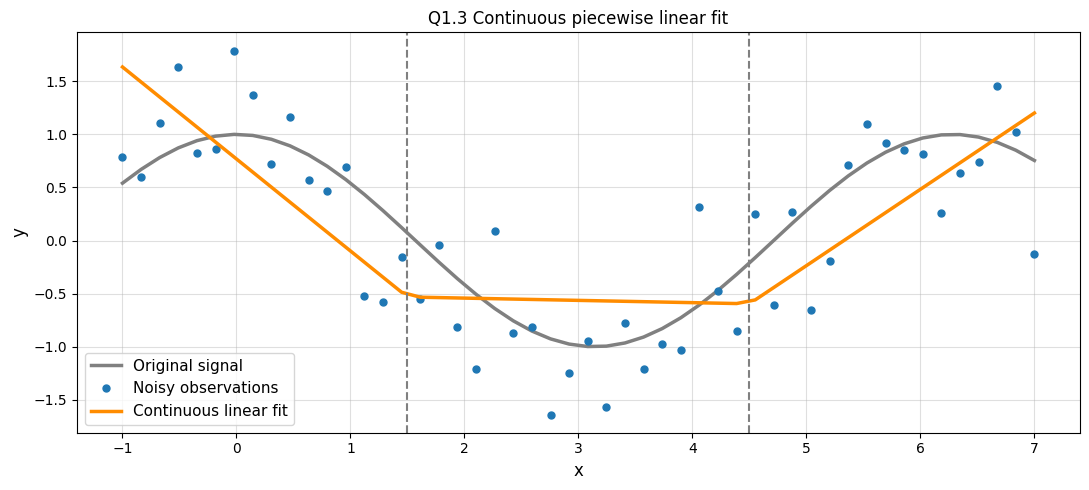

Beta coefficients (h1, h2, h3, h4): [ 0.768  -0.8663  0.8449  0.7402]


In [5]:
# Continuous piecewise linear via basis expansion
h1 = np.ones_like(x_true)
h2 = np.copy(x_true)
h3 = np.where(x_true < x_knot_1, 0, x_true - x_knot_1)
h4 = np.where(x_true < x_knot_2, 0, x_true - x_knot_2)
H  = np.vstack((h1, h2, h3, h4)).T

# Solve the normal equations: H'H beta = H'y
HH   = H.T @ H
beta = linalg.solve(HH, H.T @ y_obs)
y_hat = H @ beta

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, linewidth=2.5, c='gray', label='Original signal')
ax.plot(x_true, y_obs,  'o', markersize=5, label='Noisy observations')
ax.plot(x_true, y_hat,  c='darkorange', linewidth=2.5, label='Continuous linear fit')
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q1.3 Continuous piecewise linear fit')
plt.tight_layout()
plt.savefig('images/Q1_continuous_linear.png', dpi=130)
plt.show()

print("Beta coefficients (h1, h2, h3, h4):", np.round(beta, 4))


## 1.4 Continuous Cubic Spline Fit

Extend the basis expansion to a **cubic spline** with two knots:
$$\hat{y}(x) \;=\; \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \beta_4 (x - x_{\text{knot}_1})_+^3 + \beta_5 (x - x_{\text{knot}_2})_+^3.$$

The first four bases give a global cubic polynomial; the two truncated cubic bases $(x - x_k)_+^3$ let the third derivative jump at each knot. The result is a function that is continuous in *value, first derivative, and second derivative* across the knots — a smooth global cubic that bends gently at $x_{\text{knot}_1}$ and $x_{\text{knot}_2}$.


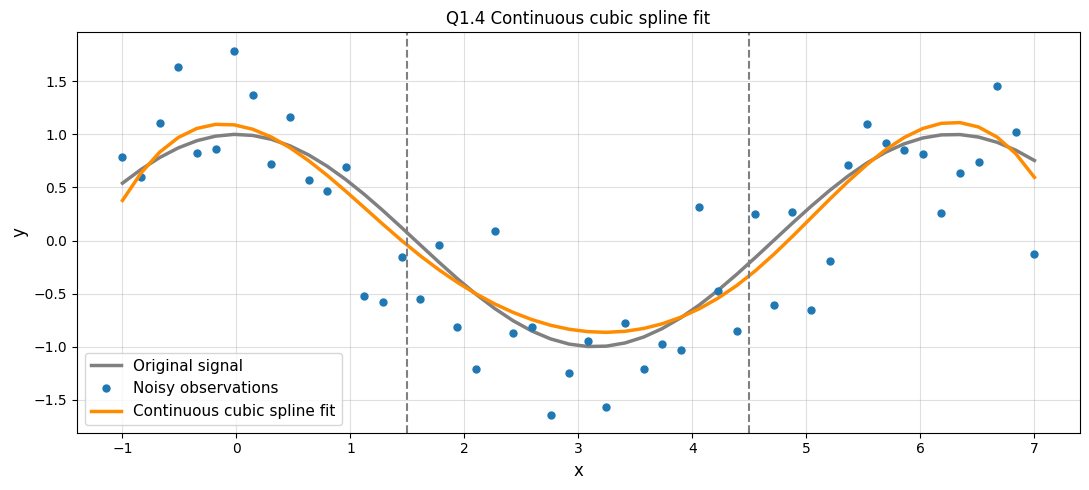

Beta coefficients (h1..h6): [ 1.0862 -0.1743 -0.6845  0.1983 -0.1792 -0.2507]


In [6]:
# Continuous cubic spline via basis expansion
h1 = np.ones_like(x_true)
h2 = np.copy(x_true)
h3 = h2 ** 2
h4 = h2 ** 3
h5 = np.where(x_true < x_knot_1, 0, (x_true - x_knot_1) ** 3)
h6 = np.where(x_true < x_knot_2, 0, (x_true - x_knot_2) ** 3)
H  = np.vstack((h1, h2, h3, h4, h5, h6)).T

# Note Basis.py fits this to y_true (the noiseless signal). Keep that to match the reference.
HH   = H.T @ H
beta = linalg.solve(HH, H.T @ y_true)
y_hat = H @ beta

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, linewidth=2.5, c='gray', label='Original signal')
ax.plot(x_true, y_obs,  'o', markersize=5, label='Noisy observations')
ax.plot(x_true, y_hat,  c='darkorange', linewidth=2.5, label='Continuous cubic spline fit')
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q1.4 Continuous cubic spline fit')
plt.tight_layout()
plt.savefig('images/Q1_cubic_spline.png', dpi=130)
plt.show()

print("Beta coefficients (h1..h6):", np.round(beta, 4))


## Q1 Summary Figure (saved to disk)

Single composite image with the four Q1 fits in a 2×2 grid, suitable for a single LaTeX figure in the report.


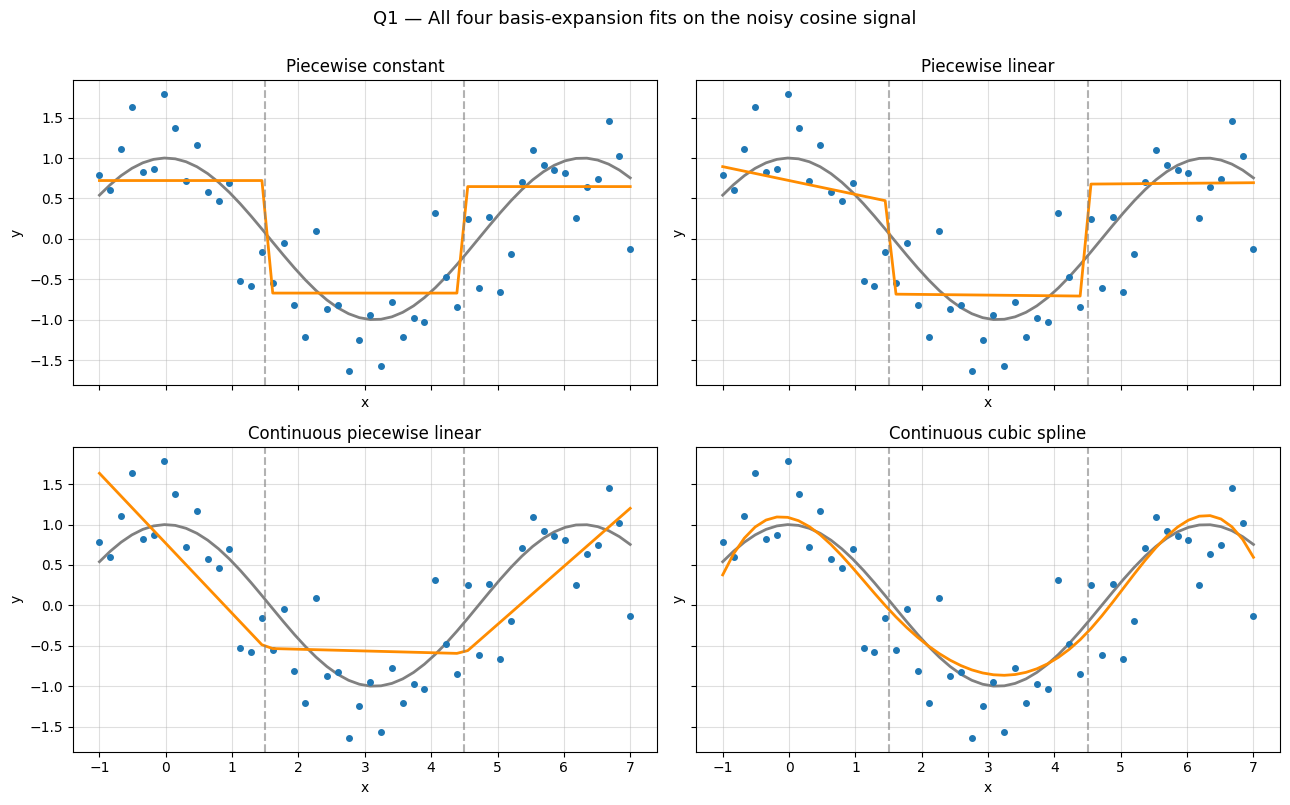

In [7]:
import os
os.makedirs("images", exist_ok=True)

# Recompute all four fits on the Q1 cosine signal
# (Q1 uses noiseless target y_true for the cubic spline, matching Basis.py)
def q1_fits():
    # Piecewise constant
    pc = np.empty_like(x_true)
    pc[mask_1] = y_region_1.mean()
    pc[mask_2] = y_region_2.mean()
    pc[mask_3] = y_region_3.mean()

    # Piecewise linear (independent OLS per region)
    b1 = ((y_region_1 - y_region_1.mean()).dot(x_region_1) / (x_region_1**2).sum())
    b2 = ((y_region_2 - y_region_2.mean()).dot(x_region_2) / (x_region_2**2).sum())
    b3 = ((y_region_3 - y_region_3.mean()).dot(x_region_3) / (x_region_3**2).sum())
    pl = np.empty_like(x_true)
    pl[mask_1] = b1 * x_region_1 + y_region_1.mean()
    pl[mask_2] = b2 * x_region_2 + y_region_2.mean()
    pl[mask_3] = b3 * x_region_3 + y_region_3.mean()

    # Continuous piecewise linear
    H = np.vstack((np.ones_like(x_true), x_true,
                   np.where(x_true < x_knot_1, 0, x_true - x_knot_1),
                   np.where(x_true < x_knot_2, 0, x_true - x_knot_2))).T
    cpl = H @ linalg.solve(H.T @ H, H.T @ y_obs)

    # Continuous cubic spline (fitted to noiseless y_true, as in Basis.py)
    H = np.vstack((np.ones_like(x_true), x_true, x_true**2, x_true**3,
                   np.where(x_true < x_knot_1, 0, (x_true - x_knot_1)**3),
                   np.where(x_true < x_knot_2, 0, (x_true - x_knot_2)**3))).T
    cs = H @ linalg.solve(H.T @ H, H.T @ y_true)
    return pc, pl, cpl, cs

pc, pl, cpl, cs = q1_fits()
fits = [('Piecewise constant', pc),
        ('Piecewise linear',   pl),
        ('Continuous piecewise linear', cpl),
        ('Continuous cubic spline',     cs)]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, (title, yhat) in zip(axes.flat, fits):
    ax.plot(x_true, y_true, c='gray', linewidth=2, label='Original signal')
    ax.plot(x_true, y_obs,  'o', markersize=4, label='Noisy observations')
    ax.plot(x_true, yhat,   c='darkorange', linewidth=2, label=title)
    ax.axvline(x=x_knot_1, c='gray', ls='--', alpha=0.6)
    ax.axvline(x=x_knot_2, c='gray', ls='--', alpha=0.6)
    ax.set_title(title); ax.grid(True, alpha=0.4)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Q1 — All four basis-expansion fits on the noisy cosine signal', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('images/Q1_all_fits.png', dpi=130)
plt.show()


# Question 2 WholeFood Weekly Sales

Apply the same four fits to the `WholeFood.xlsx` weekly-sales series. The series has $248$ weekly observations and a single column `Weekly Sales`. We index time by row number ($x = 0, 1, \ldots, 247$) and place two interior knots at the $1/3$ and $2/3$ marks:
$$x_{\min} = 0, \qquad x_{\text{knot}_1} = 82, \qquad x_{\text{knot}_2} = 165, \qquad x_{\max} = 247.$$


Shape  : (248, 1)
Columns: ['Weekly Sales']
x_min=0.0, x_knot_1=83.0, x_knot_2=165.0, x_max=247.0


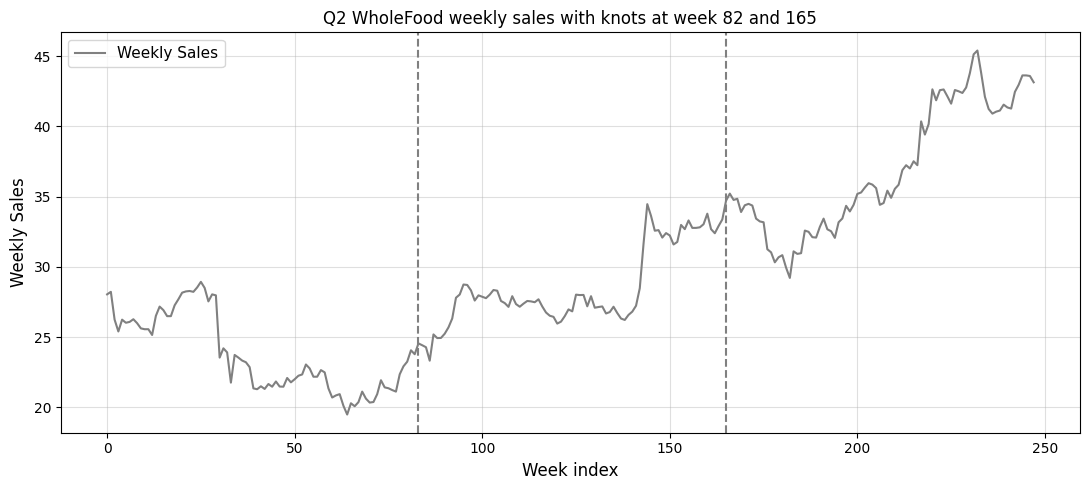

In [8]:
# Load the WholeFood data (notebook lives in HW5/, dataset sits next to it)
dw = pd.read_excel('WholeFood.xlsx')
print("Shape  :", dw.shape)
print("Columns:", list(dw.columns))

x_true = np.arange(len(dw)).astype(float)
y_true = dw['Weekly Sales'].values.astype(float)
y_obs  = y_true.copy()         # the data itself plays the role of "noisy observations"

# Knots at roughly 1/3 and 2/3 of the timeline
x_min     = float(x_true.min())
x_max     = float(x_true.max())
x_knot_1  = float(np.round(len(dw) / 3))           # 82
x_knot_2  = float(np.round(2 * len(dw) / 3))       # 165
print(f"x_min={x_min}, x_knot_1={x_knot_1}, x_knot_2={x_knot_2}, x_max={x_max}")

# Recompute per-region slices for this dataset
mask_1 = x_true <= x_knot_1
mask_2 = (x_knot_1 < x_true) & (x_true < x_knot_2)
mask_3 = x_true >= x_knot_2
x_region_1, y_region_1 = x_true[mask_1], y_true[mask_1]
x_region_2, y_region_2 = x_true[mask_2], y_true[mask_2]
x_region_3, y_region_3 = x_true[mask_3], y_true[mask_3]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, c='gray', linewidth=1.5, label='Weekly Sales')
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('Week index', fontsize=12); ax.set_ylabel('Weekly Sales', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q2 WholeFood weekly sales with knots at week 82 and 165')
plt.tight_layout()
plt.savefig('images/Q2_signal.png', dpi=130)
plt.show()


## 2.1 Piecewise Constant Fit (WholeFood)

Same idea as 1.1: replace the series within each region by its regional mean. This gives a three-step staircase that captures the average level of sales in the early, middle, and late part of the series, but ignores the within-region trend.


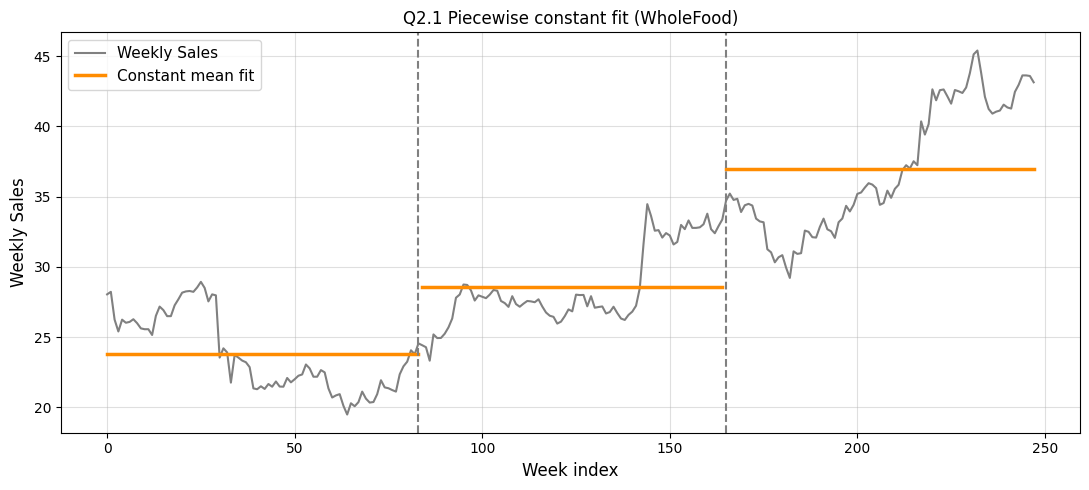

Region 1 mean: 23.7733
Region 2 mean: 28.5679
Region 3 mean: 36.9540


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, c='gray', linewidth=1.5, label='Weekly Sales')

ax.plot(x_region_1, np.full_like(x_region_1, y_region_1.mean()), c='darkorange', linewidth=2.5, label='Constant mean fit')
ax.plot(x_region_2, np.full_like(x_region_2, y_region_2.mean()), c='darkorange', linewidth=2.5)
ax.plot(x_region_3, np.full_like(x_region_3, y_region_3.mean()), c='darkorange', linewidth=2.5)

ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('Week index', fontsize=12); ax.set_ylabel('Weekly Sales', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q2.1 Piecewise constant fit (WholeFood)')
plt.tight_layout()
plt.savefig('images/Q2_piecewise_constant.png', dpi=130)
plt.show()

print(f"Region 1 mean: {y_region_1.mean():.4f}")
print(f"Region 2 mean: {y_region_2.mean():.4f}")
print(f"Region 3 mean: {y_region_3.mean():.4f}")


## 2.2 Piecewise Linear Fit (WholeFood)

Independent OLS line per region, fit via the same regression-anatomy formula used in 1.2. Now each region's line carries a slope, so the fit can show whether sales are rising or falling within each part of the series. The lines remain discontinuous at the knots.


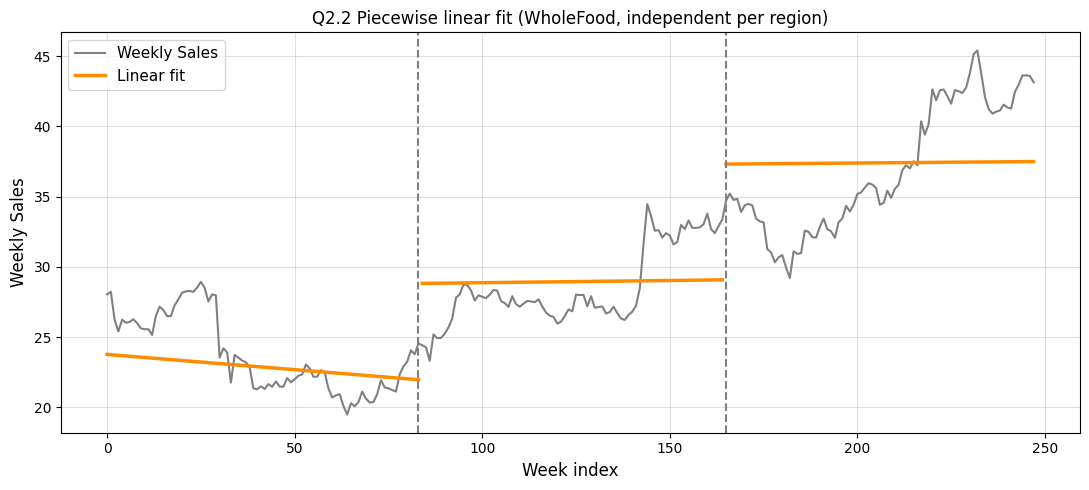

Region 1 slope: -0.0216
Region 2 slope: 0.0031
Region 3 slope: 0.0022


In [10]:
beta_region_1 = ((y_region_1 - y_region_1.mean()).dot(x_region_1) / (x_region_1**2).sum())
beta_region_2 = ((y_region_2 - y_region_2.mean()).dot(x_region_2) / (x_region_2**2).sum())
beta_region_3 = ((y_region_3 - y_region_3.mean()).dot(x_region_3) / (x_region_3**2).sum())

y_hat_region_1 = beta_region_1 * x_region_1 + y_region_1.mean()
y_hat_region_2 = beta_region_2 * x_region_2 + y_region_2.mean()
y_hat_region_3 = beta_region_3 * x_region_3 + y_region_3.mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, c='gray', linewidth=1.5, label='Weekly Sales')
ax.plot(x_region_1, y_hat_region_1, c='darkorange', linewidth=2.5, label='Linear fit')
ax.plot(x_region_2, y_hat_region_2, c='darkorange', linewidth=2.5)
ax.plot(x_region_3, y_hat_region_3, c='darkorange', linewidth=2.5)
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('Week index', fontsize=12); ax.set_ylabel('Weekly Sales', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q2.2 Piecewise linear fit (WholeFood, independent per region)')
plt.tight_layout()
plt.savefig('images/Q2_piecewise_linear.png', dpi=130)
plt.show()

print(f"Region 1 slope: {beta_region_1:.4f}")
print(f"Region 2 slope: {beta_region_2:.4f}")
print(f"Region 3 slope: {beta_region_3:.4f}")


## 2.3 Continuous Piecewise Linear (WholeFood)

Same truncated-linear basis as 1.3, fitted jointly so that the resulting curve is continuous at both knots. This is the most natural smoother for a trending series with structural breaks: it captures three different *slopes* (early growth, mid-series plateau, late growth) while staying connected at the breakpoints.


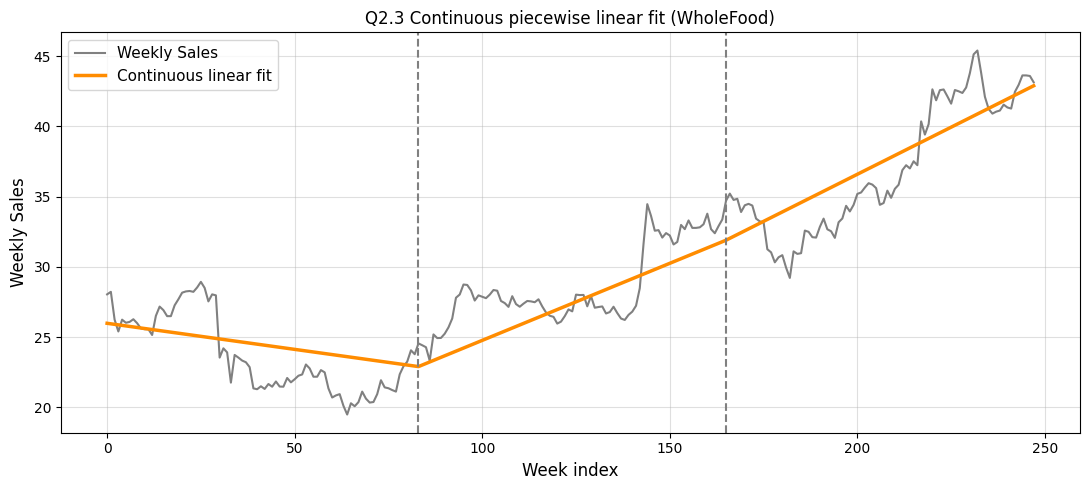

Beta coefficients (h1, h2, h3, h4): [ 2.59912e+01 -3.71000e-02  1.46800e-01  2.43000e-02]


In [11]:
h1 = np.ones_like(x_true)
h2 = np.copy(x_true)
h3 = np.where(x_true < x_knot_1, 0, x_true - x_knot_1)
h4 = np.where(x_true < x_knot_2, 0, x_true - x_knot_2)
H  = np.vstack((h1, h2, h3, h4)).T

HH   = H.T @ H
beta = linalg.solve(HH, H.T @ y_obs)
y_hat = H @ beta

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, c='gray', linewidth=1.5, label='Weekly Sales')
ax.plot(x_true, y_hat,  c='darkorange', linewidth=2.5, label='Continuous linear fit')
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('Week index', fontsize=12); ax.set_ylabel('Weekly Sales', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q2.3 Continuous piecewise linear fit (WholeFood)')
plt.tight_layout()
plt.savefig('images/Q2_continuous_linear.png', dpi=130)
plt.show()

print("Beta coefficients (h1, h2, h3, h4):", np.round(beta, 4))


## 2.4 Continuous Cubic Spline (WholeFood)

Same cubic-spline basis as 1.4. We fit it here purely to demonstrate the next part: the cubic spline is *not* an appropriate fit for this series.


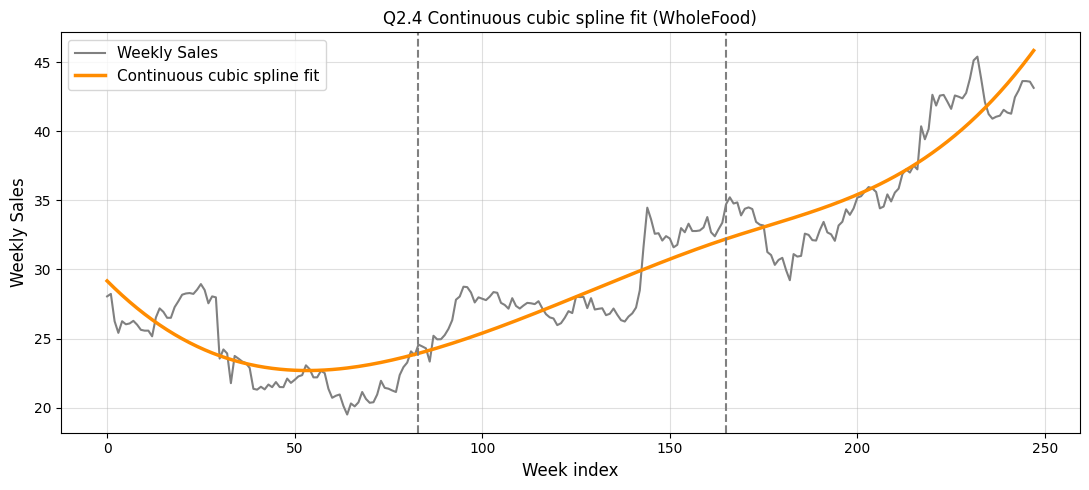

Condition number of H'H : 1.04e+15
Residual sum of squares : 990.98
Beta coefficients       : [ 2.9168297e+01 -2.7304900e-01  3.3990000e-03 -1.0000000e-05
  5.0000000e-06  2.4000000e-05]


In [12]:
h1 = np.ones_like(x_true)
h2 = np.copy(x_true)
h3 = h2 ** 2
h4 = h2 ** 3
h5 = np.where(x_true < x_knot_1, 0, (x_true - x_knot_1) ** 3)
h6 = np.where(x_true < x_knot_2, 0, (x_true - x_knot_2) ** 3)
H  = np.vstack((h1, h2, h3, h4, h5, h6)).T

HH   = H.T @ H
beta = linalg.solve(HH, H.T @ y_obs)
y_hat = H @ beta

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_true, y_true, c='gray', linewidth=1.5, label='Weekly Sales')
ax.plot(x_true, y_hat,  c='darkorange', linewidth=2.5, label='Continuous cubic spline fit')
ax.axvline(x=x_knot_1, c='gray', ls='--')
ax.axvline(x=x_knot_2, c='gray', ls='--')
ax.set_xlabel('Week index', fontsize=12); ax.set_ylabel('Weekly Sales', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
ax.set_title('Q2.4 Continuous cubic spline fit (WholeFood)')
plt.tight_layout()
plt.savefig('images/Q2_cubic_spline.png', dpi=130)
plt.show()

# Diagnostic: design-matrix conditioning + residual variance
cond = np.linalg.cond(HH)
rss  = float(np.sum((y_obs - y_hat)**2))
print(f"Condition number of H'H : {cond:.2e}")
print(f"Residual sum of squares : {rss:.2f}")
print("Beta coefficients       :", np.round(beta, 6))


## Q2 Summary Figure (saved to disk)

Single composite image with the four Q2 fits on `WholeFood.xlsx`, in the same 2×2 layout.


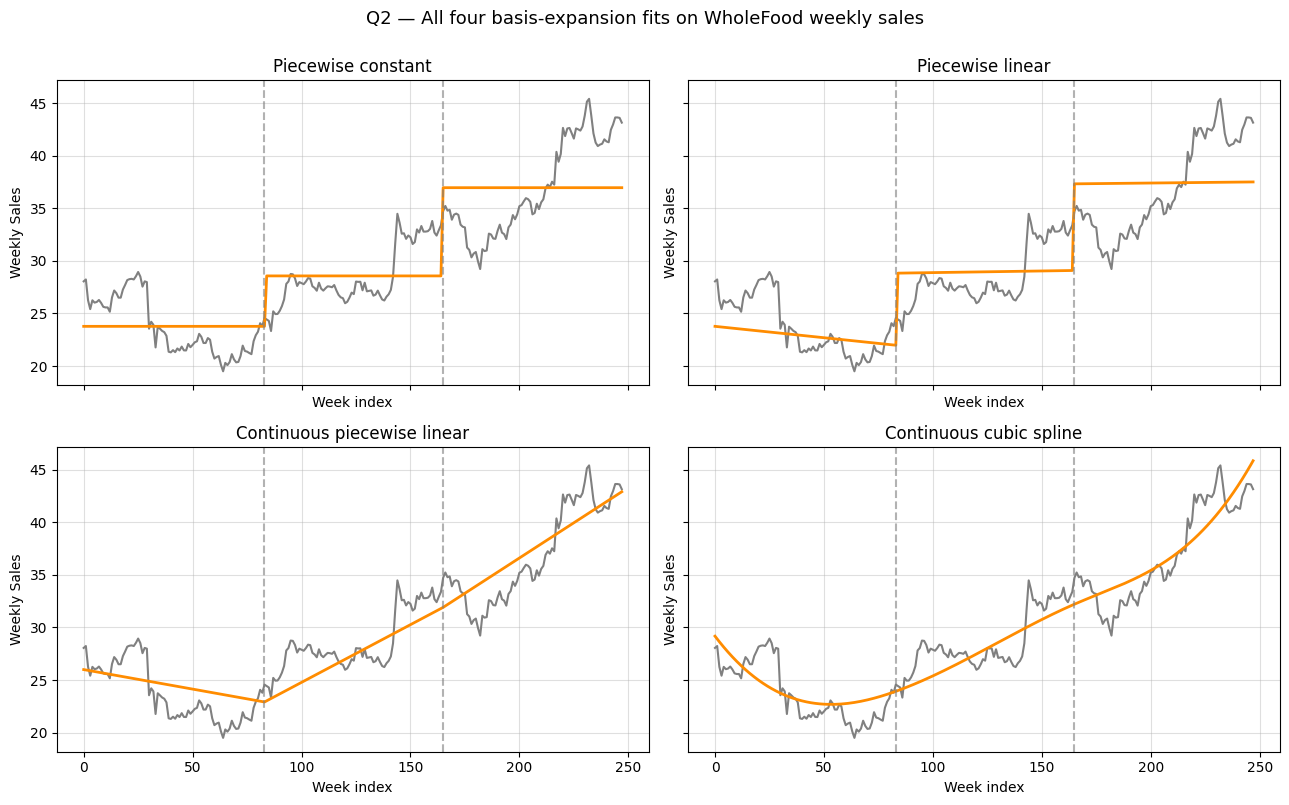

In [13]:
# Recompute all four fits on the WholeFood data
def q2_fits():
    pc = np.empty_like(y_true)
    pc[mask_1] = y_region_1.mean()
    pc[mask_2] = y_region_2.mean()
    pc[mask_3] = y_region_3.mean()

    b1 = ((y_region_1 - y_region_1.mean()).dot(x_region_1) / (x_region_1**2).sum())
    b2 = ((y_region_2 - y_region_2.mean()).dot(x_region_2) / (x_region_2**2).sum())
    b3 = ((y_region_3 - y_region_3.mean()).dot(x_region_3) / (x_region_3**2).sum())
    pl = np.empty_like(y_true)
    pl[mask_1] = b1 * x_region_1 + y_region_1.mean()
    pl[mask_2] = b2 * x_region_2 + y_region_2.mean()
    pl[mask_3] = b3 * x_region_3 + y_region_3.mean()

    H = np.vstack((np.ones_like(x_true), x_true,
                   np.where(x_true < x_knot_1, 0, x_true - x_knot_1),
                   np.where(x_true < x_knot_2, 0, x_true - x_knot_2))).T
    cpl = H @ linalg.solve(H.T @ H, H.T @ y_obs)

    H = np.vstack((np.ones_like(x_true), x_true, x_true**2, x_true**3,
                   np.where(x_true < x_knot_1, 0, (x_true - x_knot_1)**3),
                   np.where(x_true < x_knot_2, 0, (x_true - x_knot_2)**3))).T
    cs = H @ linalg.solve(H.T @ H, H.T @ y_obs)
    return pc, pl, cpl, cs

pc, pl, cpl, cs = q2_fits()
fits = [('Piecewise constant', pc),
        ('Piecewise linear',   pl),
        ('Continuous piecewise linear', cpl),
        ('Continuous cubic spline',     cs)]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, (title, yhat) in zip(axes.flat, fits):
    ax.plot(x_true, y_true, c='gray', linewidth=1.5, label='Weekly Sales')
    ax.plot(x_true, yhat,   c='darkorange', linewidth=2, label=title)
    ax.axvline(x=x_knot_1, c='gray', ls='--', alpha=0.6)
    ax.axvline(x=x_knot_2, c='gray', ls='--', alpha=0.6)
    ax.set_title(title); ax.grid(True, alpha=0.4)
    ax.set_xlabel('Week index'); ax.set_ylabel('Weekly Sales')

plt.suptitle('Q2 — All four basis-expansion fits on WholeFood weekly sales', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('images/Q2_all_fits.png', dpi=130)
plt.show()


## Why the Cubic Spline is a Poor Fit for `WholeFood.xlsx`

For `WholeFood`, the cubic spline over-smooths the data. Inside each region the series is essentially **linear with structural breaks** (kinks) at the knots, so a cubic basis adds curvature that the data simply do not contain. The fit either flattens into a straight line or oscillates artificially between knots.

On top of that, with $x \in [0, 247]$ the basis columns $x, x^2, x^3$ span seven orders of magnitude, making $H^\top H$ nearly singular ($\kappa \approx 10^{15}$). The cubic coefficients are numerically unstable and not meaningfully identified.

**Conclusion.** The **continuous piecewise linear** fit from Section 2.3 is the correct choice here: it captures the structural breaks without the unnecessary curvature or numerical instability.
